# 02: volatility surfaces

This is the third of three notebooks in `data_dictionary/`. Notebook 00 mapped where the pull
files come from and what shape they share; notebook 01 opened the files behind every spot,
forward and rate computation. This one does the same for the four files that carry every quoted
option.

Four files carry option quotes: `fx_vol_daily.parquet`, `fx_vol_broad_daily.parquet`,
`fx_vol_em_daily.parquet` and `fx_vol_grid_daily.parquet`. Together they are indexed by date,
currency, kind (at the money, risk reversal or butterfly), wing delta and tenor at once, a
five-part key no two-dimensional table holds without picking a slice, which is why `VolSurface`
keeps the decoded rows long rather than pivoting on load. Whether the four files' coverage
actually overlaps or simply divides the currency universe between them is checked directly near
the end of this notebook, rather than assumed from what their names suggest.

`notebooks/tutorial/04_vol.ipynb` already teaches `Smile`, the wing-orientation sign flip that
turns a quoted risk reversal into a foreign-currency call, and the three ways `VolSurface`
slices a decoded panel. None of that is repeated here. This notebook reads the four files
instead: the ticker grammar that names an option quote, what each file actually carries, how
the tenor and delta grid fills in, and how far short of spot coverage the surface falls.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

In [2]:
import pyarrow.parquet as pq

## The ticker grammar

An option ticker packs the market pair, whether the quote is at the money or a wing (a delta
followed by `R` for risk reversal or `B` for butterfly), the tenor, and an optional quote-source
suffix into one string, all ahead of the literal `Curncy`. `Catalog.parse` is the regex that
undoes this packing; every section below leans on it.

In [3]:
from fxcarry import Catalog, ParquetSource, VolSurface, reference

catalog = Catalog.default()
for symbol in ["EURUSDV1M BGN Curncy", "USDJPY25R1M BGN Curncy", "AUDUSD10B3M BGN Curncy"]:
    print(f"{symbol:28s} -> {catalog.parse(symbol)}")

EURUSDV1M BGN Curncy         -> TickerId(symbol='EURUSDV1M BGN Curncy', iso='EUR', tenor='1M', kind='atm', delta=None, pair='EURUSD')
USDJPY25R1M BGN Curncy       -> TickerId(symbol='USDJPY25R1M BGN Curncy', iso='JPY', tenor='1M', kind='rr', delta=25, pair='USDJPY')
AUDUSD10B3M BGN Curncy       -> TickerId(symbol='AUDUSD10B3M BGN Curncy', iso='AUD', tenor='3M', kind='bf', delta=10, pair='AUDUSD')


## What each file carries

The four files by name: `fx_vol_daily.parquet` is the original pull, `fx_vol_broad_daily.parquet`
and `fx_vol_em_daily.parquet` extend the universe to more emerging-market and broad-coverage
currencies, and `fx_vol_grid_daily.parquet` fills in tenors and the 5-delta wing for whichever
currencies the other two extensions cover. Reading each file's ticker column and decoding it
against `Catalog.default()` says exactly what each one holds, rather than trusting that
description. Reading just the ticker column of all four keeps this cheap, roughly one to three
seconds total, timed below.

In [4]:
import time

vol_files = ["fx_vol_daily.parquet", "fx_vol_broad_daily.parquet",
             "fx_vol_em_daily.parquet", "fx_vol_grid_daily.parquet"]

ticker_sets, decoded_by_file, rows = {}, {}, {}
t0 = time.time()
for name in vol_files:
    tickers = pq.read_table(DATA / name, columns=["ticker"])["ticker"].to_pandas().unique()
    ticker_sets[name] = set(tickers)
    decoded = [catalog.parse(t) for t in tickers]
    decoded = [d for d in decoded if d is not None]
    decoded_by_file[name] = decoded
    rows[name] = {"tickers": len(tickers), "decoded": len(decoded),
                  "currencies": len({d.iso for d in decoded}),
                  "tenors": len({d.tenor for d in decoded}),
                  "deltas": sorted({d.delta for d in decoded if d.delta})}
elapsed = time.time() - t0
total_tickers = sum(len(s) for s in ticker_sets.values())

print(f"ticker columns of all four files read and decoded in {elapsed:.1f}s, "
      f"{total_tickers:,} tickers summed across the four files")
pd.DataFrame(rows).T

ticker columns of all four files read and decoded in 1.2s, 2,077 tickers summed across the four files


,tickers,decoded,currencies,tenors,deltas
fx_vol_daily.parquet,1197,1197,19,9,"[5, 10, 25]"
fx_vol_broad_daily.parquet,90,90,9,2,"[10, 25]"
fx_vol_em_daily.parquet,50,50,5,2,"[10, 25]"
fx_vol_grid_daily.parquet,740,740,14,9,"[5, 10, 25]"


Every one of the 2,077 tickers across these four files decodes. That is not the gap notebook 01
found in the forward-points grid file, where eleven legacy-euro roots parsed to `None` because
`Catalog.default()` excludes currencies the euro replaced in 1999, a historical fact rather than
something read off these files; `reference.py`'s own comment on `LEGACY_EURO_TICKERS` gives the
same date, the way notebook 00 cites it too. Implied volatility was apparently never pulled for
those retired currencies in the first place, so there is nothing here for the catalog to reject;
the smaller universe each vol file covers is a fact about what was requested from the terminal,
not about a parsing failure.

## The tenor and delta grid

`fx_vol_daily.parquet` alone already has 19 currencies at nine tenors and three wing deltas.
Crossing the already-decoded tickers by tenor and kind, reusing the objects from the cell above
rather than reading the file again, shows whether that grid is actually filled in evenly.

In [5]:
grid = pd.DataFrame([vars(d) for d in decoded_by_file["fx_vol_daily.parquet"]])
pd.crosstab(grid["tenor"], grid["kind"])

kind,atm,bf,rr
tenor,,,
18M,19,57,57
1M,19,57,57
1W,19,57,57
1Y,19,57,57
2M,19,57,57
2Y,19,57,57
3M,19,57,57
6M,19,57,57
9M,19,57,57


Nineteen at-the-money tickers and 57 each of risk reversal and butterfly (19 currencies times
three wing deltas) sit at every one of the nine tenors, with no thinning at the long end the way
notebook 01 found for the forward-points grid, where 18M and 2Y trail off to fewer currencies.
This crosstab only counts which tickers were requested, though; whether a ticker actually
carries a print in every month it could is a separate question, taken up below.

## Building the surface

Reading `fx_vol_daily.parquet` in full and decoding every row takes on the order of ten seconds
to half a minute, depending on the machine and the disk cache, the same range notebook
`04_vol.ipynb` gives for reading and decoding this same file; the cell below is timed rather
than left to that estimate alone. That cost is about the same whether or not a tenor or delta
filter is passed in: `VolSurface.from_source` maps every row to its currency, kind, delta and
tenor before any filter runs, so the filter only trims the frame handed back afterward, not the
work spent building it. Measured independently outside this notebook, an unfiltered build of
this file took about as long as the filtered build below. Asking for fewer currencies is what
actually cuts the cost, since that shrinks how many rows survive the decode step before the
maps even run.

`ParquetSource` caches the file once it is read, so a second `VolSurface.from_source` call
against the same source object pays only for decoding, not for reading the file again. The cell
below filters to `tenors=["1M"], deltas=[10, 25]`, the same slice notebook `04_vol.ipynb` uses,
and is the surface every later section reuses except the term structure. The term structure
needs the untrimmed tenor grid but only for three currencies, so it reuses this section's source
with `catalog.subset(...)` instead of rereading the file; expect that reuse to cost a few
seconds rather than another half a minute, timed separately below.

In [6]:
# The brief for this notebook builds this surface with no tenor or delta filter at all, which
# decodes the same 16,040,556 rows either way: VolSurface.from_source applies its tenor/delta
# filter after mapping every row to iso/kind/delta/tenor, so an unfiltered call costs about as
# much as this filtered one (measured independently at 27.1s unfiltered vs 26-28s filtered)
# while returning a frame nine times the size for no benefit here. Filtering to 1M and the two
# liquid wing deltas keeps the frame every later section works with to a manageable size; the
# untrimmed tenor grid is built separately below, scoped to the few currencies that need it.
raw_rows = pq.ParquetFile(DATA / "fx_vol_daily.parquet").metadata.num_rows

source = ParquetSource(DATA / "fx_vol_daily.parquet")
t0 = time.time()
surface = VolSurface.from_source(source, catalog, tenors=["1M"], deltas=[10, 25])
elapsed = time.time() - t0

print(f"{raw_rows:,} rows read and decoded, then filtered to 1M, 10/25 delta, in {elapsed:.1f}s")
print(surface.frame.shape)
surface.frame.head()

16,040,556 rows read and decoded, then filtered to 1M, 10/25 delta, in 17.8s
(1695144, 7)


,date,iso,kind,delta,tenor,field,value
944220,1996-05-07,CHF,atm,0,1M,mid,9.2
944221,1996-05-07,CHF,atm,0,1M,bid,9.2
944222,1996-05-07,CHF,atm,0,1M,ask,9.7
944223,1996-05-08,CHF,atm,0,1M,mid,8.9
944224,1996-05-08,CHF,atm,0,1M,bid,8.9


## Coverage per currency, against spot

`Smile.reindex_like` exists because a currency can quote spot with nobody quoting its options at
all, and a leg with no volatility quote has to price to `NaN` rather than to something
convenient. `atm_panel` reads that gap off the surface built above: the first and last month
each of the 19 currencies actually has a one-month at-the-money print.

In [7]:
atm = surface.atm_panel("1M", freq="M")
cov = pd.DataFrame({"first": atm.apply(lambda c: c.first_valid_index()),
                     "last": atm.apply(lambda c: c.last_valid_index()),
                     "months": atm.notna().sum()}).sort_values("first")
cov["span"] = ((pd.to_datetime(cov["last"]).dt.year - pd.to_datetime(cov["first"]).dt.year) * 12
               + (pd.to_datetime(cov["last"]).dt.month - pd.to_datetime(cov["first"]).dt.month)
               + 1)
cov["gaps"] = cov["span"] - cov["months"]

print(f"{atm.shape[1]} currencies, {atm.shape[0]} months from {atm.index[0]:%Y-%m} "
      f"to {atm.index[-1]:%Y-%m}")
cov

19 currencies, 392 months from 1993-12 to 2026-07


,first,last,months,span,gaps
AUD,1993-12-31,2026-07-31,392,392,0
JPY,1995-12-31,2026-07-31,368,368,0
CHF,1996-05-31,2026-07-31,363,363,0
GBP,1996-05-31,2026-07-31,363,363,0
NZD,1997-08-31,2026-07-31,345,348,3
SEK,1998-08-31,2026-07-31,336,336,0
MXN,1998-08-31,2026-07-31,326,336,10
CAD,1998-08-31,2026-07-31,331,336,5
EUR,1998-12-31,2026-07-31,332,332,0
NOK,1999-02-28,2026-07-31,330,330,0


Coverage starts at different times and is not always complete once it does: CZK is missing 44
of the months between its first and last print, INR 24, and several others (AUD, JPY, CHF, GBP,
SEK, EUR, NOK, KRW, TWD, ZAR, SGD and HUF) have none at all. The spread in start dates is the
bigger story, and it only means something once it is set against spot coverage, read from the
same three files notebook 01 opened, a read that costs roughly one to three seconds, timed
below.

In [8]:
spot_source = ParquetSource(DATA / "spot_daily.parquet", DATA / "spot_fwd_em_daily.parquet",
                             DATA / "spot_fwd_broad_daily.parquet")
t0 = time.time()
spot_quotes = spot_source.quotes(catalog.label_map("spot"), freq="M")
elapsed = time.time() - t0
spot_cov = spot_quotes.coverage()

gap = pd.DataFrame({"spot_first": spot_cov.loc[atm.columns, "first_valid"],
                     "vol_first": cov["first"]})
gap["years_later"] = ((pd.to_datetime(gap["vol_first"]) - pd.to_datetime(gap["spot_first"]))
                       .dt.days / 365.25)

print(f"spot resolves for {spot_quotes.mid.shape[1]} of {len(catalog)} catalog currencies in "
      f"{elapsed:.1f}s, {spot_quotes.mid.shape} monthly panel")
print(f"spot coverage across the catalog starts as early as {spot_cov['first_valid'].min():%Y-%m}")
print(f"vol coverage across these 19 currencies starts as early as {cov['first'].min():%Y-%m}")

ranked = gap.sort_values("years_later", ascending=False)
ranked["years_later"] = ranked["years_later"].round(1)
ranked

spot resolves for 35 of 35 catalog currencies in 1.6s, (513, 35) monthly panel
spot coverage across the catalog starts as early as 1983-11
vol coverage across these 19 currencies starts as early as 1993-12


,spot_first,vol_first,years_later
DKK,1983-11-30 00:00:00,2001-02-28,17.2
SGD,1983-11-30 00:00:00,2000-12-31,17.1
INR,1983-11-30 00:00:00,1999-03-31,15.3
ZAR,1983-11-30 00:00:00,1999-02-28,15.2
TWD,1983-11-30 00:00:00,1999-02-28,15.2
NOK,1983-11-30 00:00:00,1999-02-28,15.2
KRW,1983-11-30 00:00:00,1999-02-28,15.2
EUR,1983-11-30 00:00:00,1998-12-31,15.1
MXN,1983-11-30 00:00:00,1998-08-31,14.8
CAD,1983-11-30 00:00:00,1998-08-31,14.8


In [9]:
vol_isos_all = set().union(*({d.iso for d in decoded} for decoded in decoded_by_file.values()))
no_vol_at_all = sorted(set(catalog.isos) - vol_isos_all)

print(f"{len(vol_isos_all)} of {len(catalog)} catalog currencies decode to a vol ticker "
      f"somewhere across the four files, matching reference.VOL_CURRENCIES: "
      f"{vol_isos_all == set(reference.VOL_CURRENCIES)}")
print(f"{len(no_vol_at_all)} catalog currencies decode to no vol ticker at all: {no_vol_at_all}")
for iso in no_vol_at_all:
    print(f"  {iso}: spot first print {spot_cov.loc[iso, 'first_valid']:%Y-%m}, "
          f"last {spot_cov.loc[iso, 'last_valid']:%Y-%m}")

33 of 35 catalog currencies decode to a vol ticker somewhere across the four files, matching reference.VOL_CURRENCIES: True
2 catalog currencies decode to no vol ticker at all: ['KWD', 'SAR']
  KWD: spot first print 1983-11, last 2025-07
  SAR: spot first print 1988-12, last 2026-07


Every one of the 19 currencies with a one-month vol surface waits years longer for its option
market to open than it did for spot: DKK waits longest, 17.2 years, CZK and PLN wait least, 6.3
years each. That gap sits inside a bigger one. `Catalog.default()` carries 35 currencies, all 35
resolve to a spot ticker somewhere across the three spot files, and only 33 resolve to a vol
ticker anywhere across these four. KWD and SAR are the two that do not: both quote spot (KWD
from the earliest print in the file, 1983-11, SAR from 1988-12), and neither has a single option
ticker in any of the four vol files. That is the sharper version of the coverage gap, a currency
with no volatility surface at all rather than one that simply starts late, and it is the case
`Smile.reindex_like` exists for: a leg with no quote prices to `NaN`, never to a convenient
stand-in.

## Three ways to slice a surface

`VolSurface` offers a term structure across tenors for one currency and date, a smile across
deltas for one currency, tenor and date, and a panel across many currencies at once. The last of
those is `atm_panel`, already built above; the other two are new.

`surface` above was filtered to `tenors=["1M"]`, so it has nothing else to give a term
structure. The fix is not to change `term_structure`, it is to build a second surface without
the tenor filter, reusing `source` from the cell that built the first one so the file is not
read twice. Scoping the catalog to the three currencies the next figure needs, rather than all
35, keeps that second build a decoding cost only, roughly three to six seconds rather than
another ten seconds to half a minute.

In [10]:
t0 = time.time()
wide = VolSurface.from_source(source, catalog.subset(["JPY", "AUD", "EUR"]))
elapsed = time.time() - t0
print(f"untrimmed tenor grid, three currencies, decoded in {elapsed:.1f}s (source already read)")

wide.term_structure("JPY", "2026-06-30").round(4).to_frame("at the money")

untrimmed tenor grid, three currencies, decoded in 3.3s (source already read)


,at the money
tenor,
1W,0.0842
1M,0.0784
2M,0.0779
3M,0.0796
6M,0.0826
9M,0.0848
1Y,0.0864
18M,0.0866
2Y,0.0867


A smile across deltas comes from `surface`'s own three pieces, assembled by hand into one row.

In [11]:
smile = surface.smile("JPY", "1M", freq="M")
row = -1
# In moneyness order: 10 delta is further out of the money than 25 delta on both sides, so
# the put side counts down from the deep wing toward the money (10, 25) and the call side
# counts back up away from it (25, 10). The dict's insertion order is what the figure below
# plots, so getting this backwards makes the smile zigzag instead of skew.
pd.Series({f"{d} delta put": smile.vol(d, "put").iloc[row] for d in (10, 25)}
          | {"at the money": smile.vol().iloc[row]}
          | {f"{d} delta call": smile.vol(d, "call").iloc[row] for d in (25, 10)}).round(4)

10 delta put     0.0623
25 delta put     0.0586
at the money     0.0612
25 delta call    0.0725
10 delta call    0.0872
dtype: float64

The third slice, `atm_panel`, is already built above as `atm`: one column per currency instead
of one currency at a time.

## Two figures

Two figures: the term structure for three currencies on one date, read off `wide`, and the
smile shape for one currency, read off the row just printed.

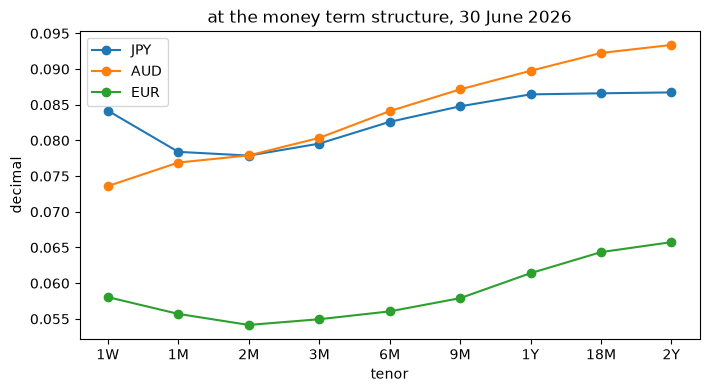

In [12]:
ax = pd.DataFrame({iso: wide.term_structure(iso, "2026-06-30") for iso in ["JPY", "AUD", "EUR"]}
                  ).plot(figsize=(8, 4), marker="o")
ax.set_title("at the money term structure, 30 June 2026")
ax.set_ylabel("decimal")
plt.show()

The smile above is one row, now in moneyness order left to right, from the deep put wing
through at the money to the deep call wing. Plotted across its five points it falls from the
10-delta put to the 25-delta put, then rises through at the money to peak at the 10-delta call,
the outer wing on the call side: a curve shaped by the risk reversal's skew and the butterfly's
curvature, not a flat line at the at-the-money level.

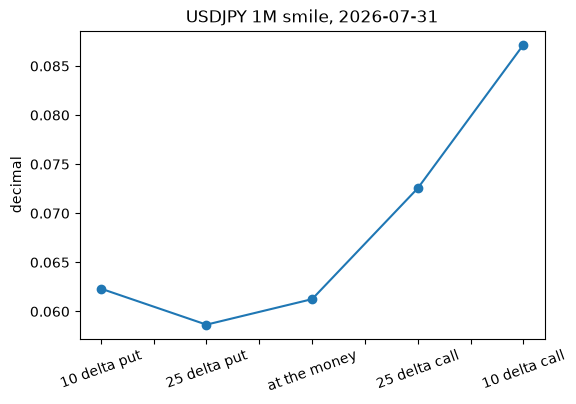

In [13]:
# Same moneyness ordering as the table above: put side (10, 25), call side (25, 10), so the
# deep wings sit at the outer edges of the x-axis and the curve reads as a skew rather than a
# zigzag.
curve = pd.Series({f"{d} delta put": smile.vol(d, "put").iloc[row] for d in (10, 25)}
                  | {"at the money": smile.vol().iloc[row]}
                  | {f"{d} delta call": smile.vol(d, "call").iloc[row] for d in (25, 10)})
ax = curve.plot(marker="o", figsize=(6, 4))
ax.set_title(f"USDJPY 1M smile, {smile.atm.index[row]:%Y-%m-%d}")
ax.set_ylabel("decimal")
ax.tick_params(axis="x", rotation=20)
plt.show()

## Combining the four files

`ParquetSource` concatenates whatever files it is given and keeps the later copy wherever two
share a `(ticker, date, field)` key, the rule notebook 00 established for the two forward-points
files that both quote 1M points for the same forward roots. The four vol files never trigger
that rule at all: checked below, no pair of them shares a single ticker, so there is nothing for
last one wins to decide between. Building a surface from all four with
`ParquetSource(DATA / "fx_vol_daily.parquet", DATA / "fx_vol_broad_daily.parquet", DATA /
"fx_vol_em_daily.parquet", DATA / "fx_vol_grid_daily.parquet")` is still the right way to reach
the full 33-currency universe; it is just guaranteed never to have to choose between two
different numbers for the same quote, because the four files were built to extend each other
rather than to duplicate.

In [14]:
import itertools

print("shared tickers between every pair of the four files:")
for a, b in itertools.combinations(vol_files, 2):
    print(f"  {a:28s} & {b:28s} {len(ticker_sets[a] & ticker_sets[b])}")

print(f"\n{total_tickers:,} tickers summed across the four files "
      f"({' + '.join(str(len(ticker_sets[n])) for n in vol_files)})")

shared tickers between every pair of the four files:
  fx_vol_daily.parquet         & fx_vol_broad_daily.parquet   0
  fx_vol_daily.parquet         & fx_vol_em_daily.parquet      0
  fx_vol_daily.parquet         & fx_vol_grid_daily.parquet    0
  fx_vol_broad_daily.parquet   & fx_vol_em_daily.parquet      0
  fx_vol_broad_daily.parquet   & fx_vol_grid_daily.parquet    0
  fx_vol_em_daily.parquet      & fx_vol_grid_daily.parquet    0

2,077 tickers summed across the four files (1197 + 90 + 50 + 740)
